# PERSONAGE Investigation — Slide-Ready Visualizations

Publication-quality figures summarizing the full pipeline: prompt engineering → multi-model benchmark → held-out test → E-improvement.

In [1]:
import json, os
import numpy as np
import pandas as pd
from scipy import stats
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import glob as g

plt.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 300, "savefig.bbox": "tight",
    "axes.titlesize": 13, "axes.labelsize": 11,
    "font.size": 10, "legend.fontsize": 9,
    "axes.spines.top": False, "axes.spines.right": False,
})

TRAITS = ["O", "C", "E", "A", "N"]
TN = {"O": "Openness", "C": "Conscientiousness", "E": "Extraversion", "A": "Agreeableness", "N": "Neuroticism"}
COLORS = {"O": "#2196F3", "C": "#4CAF50", "E": "#F44336", "A": "#FF9800", "N": "#9C27B0"}
BASELINE = 0.457

RES = Path("../results")
P3 = Path("../phase3/results")
DATA = Path("../data")

def load(base, pattern):
    rows = []
    for fp in sorted(base.glob(pattern)):
        for line in open(fp):
            r = json.loads(line.strip())
            if r.get("detected_ocean"):
                rows.append(r)
    seen = {}
    for r in rows:
        seen[r.get("sample_id", r.get("id"))] = r
    return list(seen.values())

def pearson_mae(rows, t, e_cal=None):
    pairs = [(r["detected_ocean"][t], r["ground_truth_ocean"][t])
             for r in rows if t in r.get("ground_truth_ocean", {}) and t in r.get("detected_ocean", {})]
    if len(pairs) < 5:
        return np.nan, np.nan, np.nan, 0
    p, gt = np.array([x[0] for x in pairs]), np.array([x[1] for x in pairs])
    if t == "E" and e_cal:
        p = np.clip(e_cal[0]*p + e_cal[1], -1, 1)
    r, _ = stats.pearsonr(p, gt)
    return r, np.mean(np.abs(p - gt)), np.mean(p - gt), len(pairs)

In [2]:
# Load everything
v1_test = load(P3, "phase3_v1_test_*.jsonl")
v2_test = load(P3, "phase3_v2_test_*.jsonl")
v1_dev  = load(RES, "harness_trait_first_s11_t03*.jsonl")

# Phase 2 models
model_keys = ["llama-3.3-70b", "gpt-5.1", "gemini-3-flash", "grok-4", "qwen3.5-397b", "claude-sonnet-4.6", "deepseek-chat"]
model_labels = ["Llama 3.3\n70B", "GPT-5.1", "Gemini 3\nFlash", "Grok 4", "Qwen 3.5\n397B", "Claude\nSonnet 4.6", "DeepSeek\nChat"]
model_data = {}
for mk in model_keys:
    model_data[mk] = load(RES, f"benchmark_{mk}_dev_*.jsonl")

# E calibration
e_p = np.array([r["detected_ocean"]["E"] for r in v1_dev if "E" in r.get("ground_truth_ocean", {})])
e_g = np.array([r["ground_truth_ocean"]["E"] for r in v1_dev if "E" in r.get("ground_truth_ocean", {})])
slope, intercept, _, _, _ = stats.linregress(e_p, e_g)

print(f"Loaded: v1_test={len(v1_test)}, v2_test={len(v2_test)}, v1_dev={len(v1_dev)}")
print(f"Models: {[f'{k}({len(v)})' for k,v in model_data.items()]}")
print(f"E calibration: {slope:.4f}*E + ({intercept:+.4f})")

Loaded: v1_test=288, v2_test=288, v1_dev=80
Models: ['llama-3.3-70b(80)', 'gpt-5.1(80)', 'gemini-3-flash(63)', 'grok-4(80)', 'qwen3.5-397b(80)', 'claude-sonnet-4.6(74)', 'deepseek-chat(78)']
E calibration: 0.6521*E + (-0.0172)


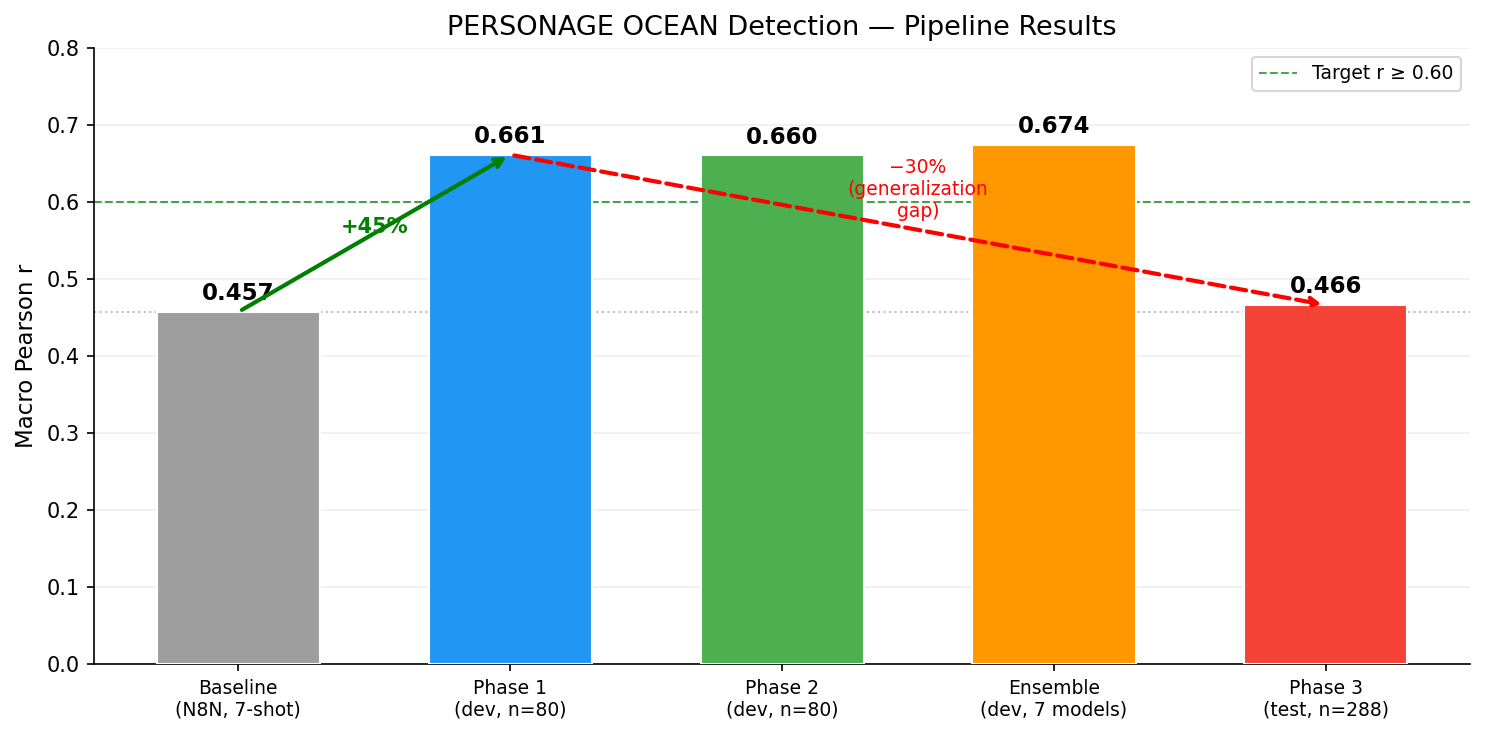

In [3]:
# ═══════════════════════════════════════════════════════════════════
# SLIDE 1: Pipeline Overview — Baseline → Optimized → Test (waterfall)
# ═══════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 5))

stages = ["Baseline\n(N8N, 7-shot)", "Phase 1\n(dev, n=80)", "Phase 2\n(dev, n=80)", "Ensemble\n(dev, 7 models)", "Phase 3\n(test, n=288)"]
values = [0.457, 0.661, 0.660, 0.674, 0.466]
colors_bar = ["#9E9E9E", "#2196F3", "#4CAF50", "#FF9800", "#F44336"]

bars = ax.bar(range(len(stages)), values, color=colors_bar, edgecolor="white", width=0.6, zorder=3)
ax.set_xticks(range(len(stages)))
ax.set_xticklabels(stages, fontsize=9)
ax.set_ylabel("Macro Pearson r")
ax.set_title("PERSONAGE OCEAN Detection — Pipeline Results")
ax.set_ylim(0, 0.8)
ax.axhline(0.60, color="green", ls="--", lw=1, alpha=0.7, label="Target r ≥ 0.60")
ax.axhline(BASELINE, color="gray", ls=":", lw=1, alpha=0.5)

for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.015, f"{v:.3f}", ha="center", fontsize=11, fontweight="bold")

# Arrow annotations
ax.annotate("", xy=(1, 0.661), xytext=(0, 0.457),
            arrowprops=dict(arrowstyle="->", color="green", lw=2))
ax.text(0.5, 0.56, "+45%", ha="center", fontsize=10, color="green", fontweight="bold")

ax.annotate("", xy=(4, 0.466), xytext=(1, 0.661),
            arrowprops=dict(arrowstyle="->", color="red", lw=2, ls="--"))
ax.text(2.5, 0.58, "−30%\n(generalization\ngap)", ha="center", fontsize=9, color="red")

ax.legend(loc="upper right", fontsize=9)
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig("slide_pipeline_overview.png")
plt.show()

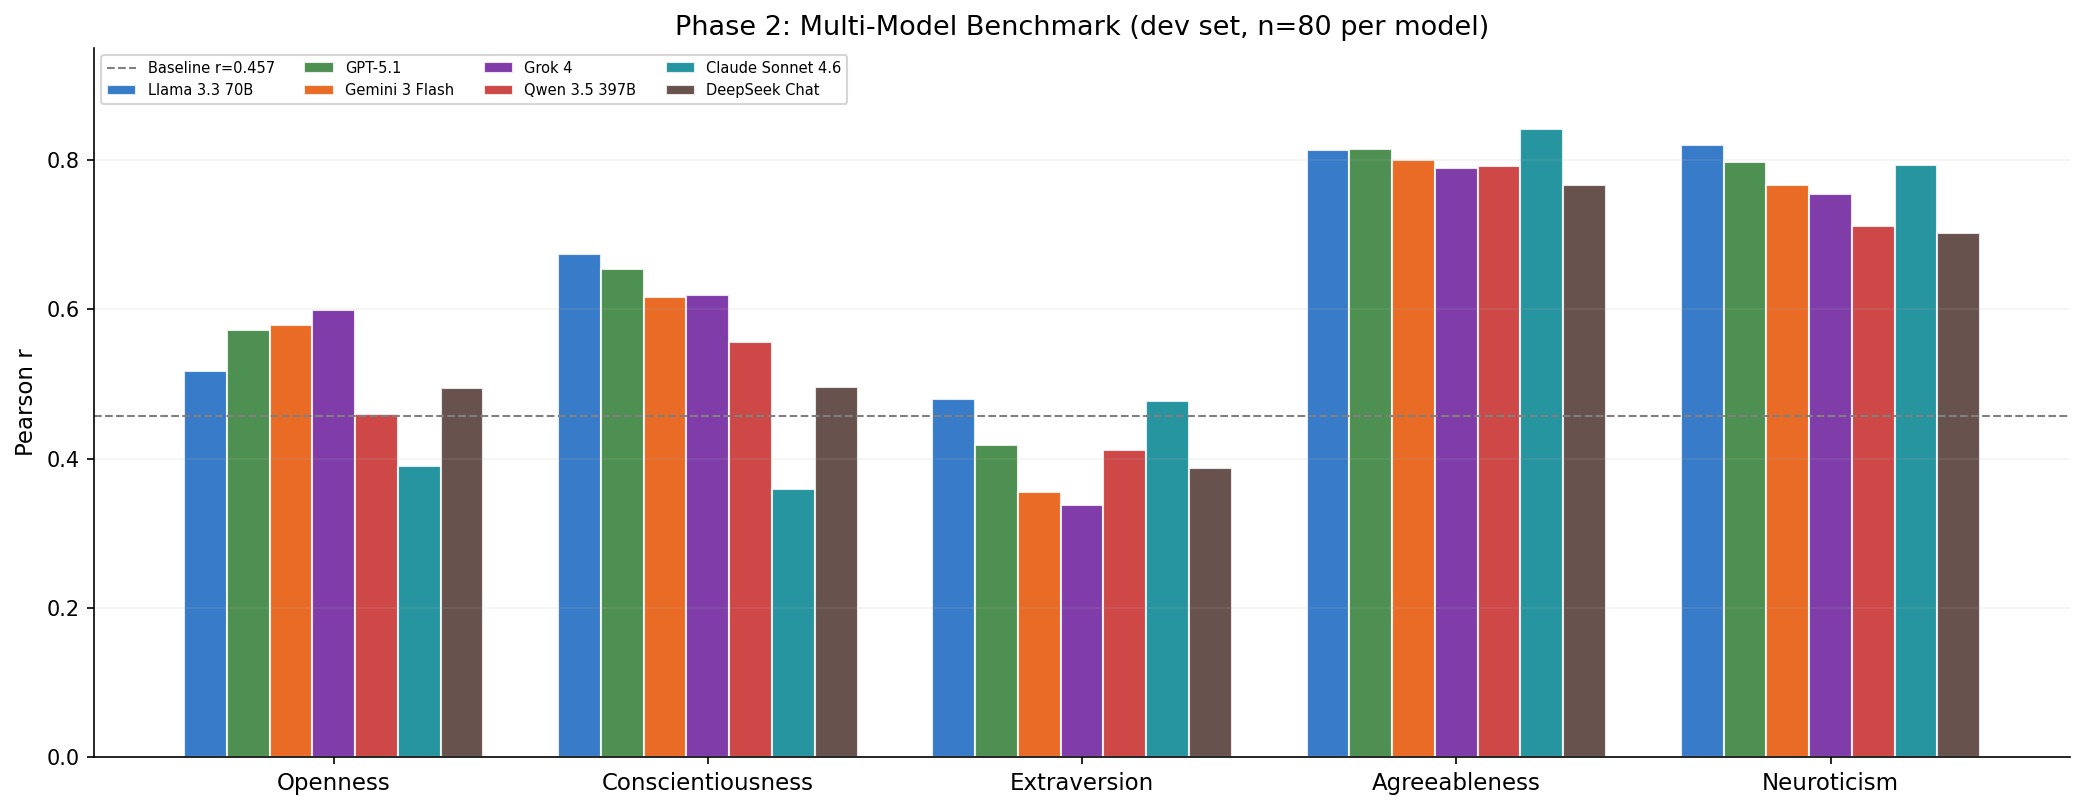

In [4]:
# ═══════════════════════════════════════════════════════════════════
# SLIDE 2: Multi-Model Benchmark — Grouped bars per trait (dev)
# ═══════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 5.5))

n_models = len(model_keys)
x = np.arange(5)
w = 0.8 / n_models
model_colors = ["#1565C0", "#2E7D32", "#E65100", "#6A1B9A", "#C62828", "#00838F", "#4E342E"]

for i, (mk, ml, mc) in enumerate(zip(model_keys, model_labels, model_colors)):
    rows = model_data[mk]
    rs = [pearson_mae(rows, t)[0] for t in TRAITS]
    bars = ax.bar(x + i*w - 0.4 + w/2, rs, w, label=ml.replace('\n',' '), color=mc, edgecolor="white", alpha=0.85)

ax.axhline(BASELINE, color="gray", ls="--", lw=1, label=f"Baseline r={BASELINE}")
ax.set_xticks(x)
ax.set_xticklabels([TN[t] for t in TRAITS], fontsize=11)
ax.set_ylabel("Pearson r")
ax.set_title("Phase 2: Multi-Model Benchmark (dev set, n=80 per model)")
ax.set_ylim(0, 0.95)
ax.legend(loc="upper left", fontsize=7, ncol=4)
ax.grid(axis="y", alpha=0.15)
plt.tight_layout()
plt.savefig("slide_multimodel_benchmark.png")
plt.show()

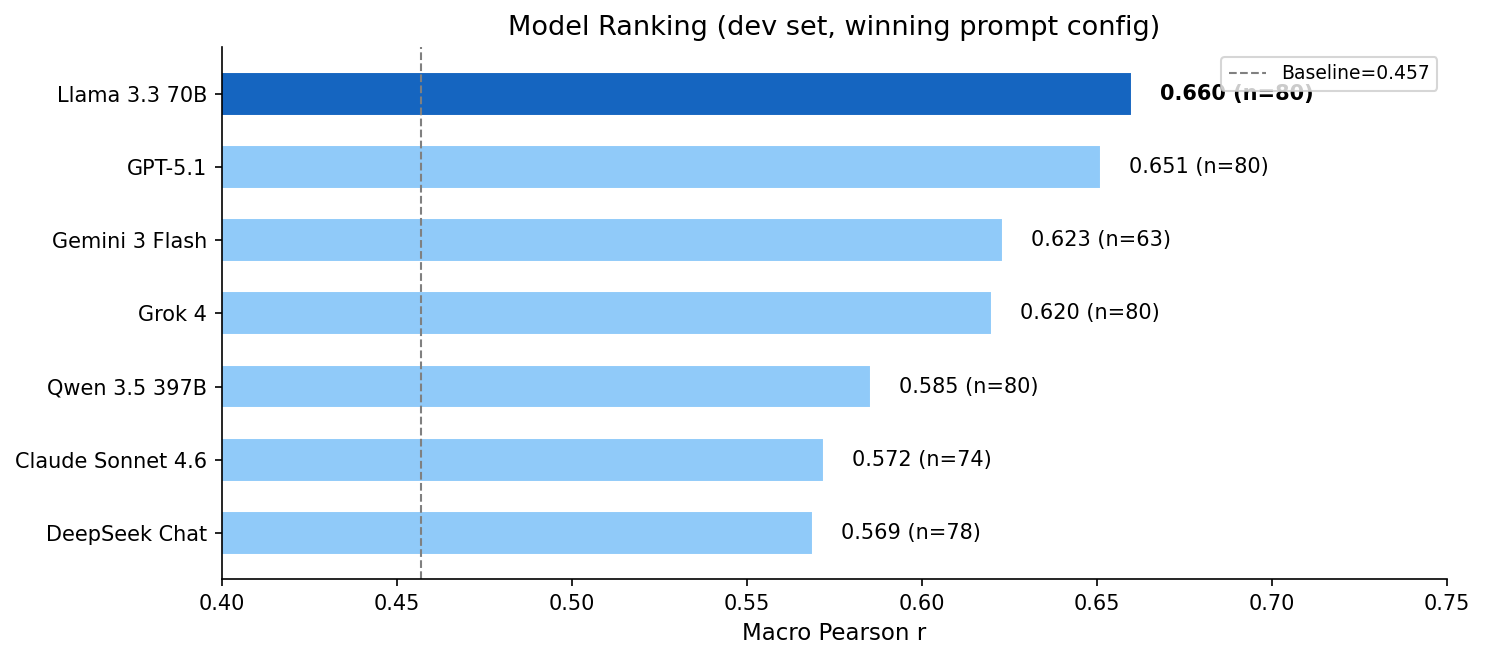

In [5]:
# ═══════════════════════════════════════════════════════════════════
# SLIDE 3: Model Ranking — Horizontal bar chart (dev, macro r)
# ═══════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 4.5))

ranking = []
for mk, ml in zip(model_keys, model_labels):
    rows = model_data[mk]
    rs = [pearson_mae(rows, t)[0] for t in TRAITS]
    valid_rs = [r for r in rs if not np.isnan(r)]
    ranking.append((ml.replace('\n',' '), np.mean(valid_rs) if valid_rs else 0, len(rows)))
ranking.sort(key=lambda x: x[1])

labels, vals, ns = zip(*ranking)
colors_rank = ["#1565C0" if v == max(vals) else "#90CAF9" for v in vals]
bars = ax.barh(range(len(labels)), vals, color=colors_rank, edgecolor="white", height=0.6)
ax.axvline(BASELINE, color="gray", ls="--", lw=1, label=f"Baseline={BASELINE}")
for i, (bar, v, n) in enumerate(zip(bars, vals, ns)):
    ax.text(v + 0.008, i, f"{v:.3f} (n={n})", va="center", fontsize=10, fontweight="bold" if v == max(vals) else "normal")

ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel("Macro Pearson r")
ax.set_title("Model Ranking (dev set, winning prompt config)")
ax.legend(fontsize=9)
ax.set_xlim(0.4, 0.75)
plt.tight_layout()
plt.savefig("slide_model_ranking.png")
plt.show()

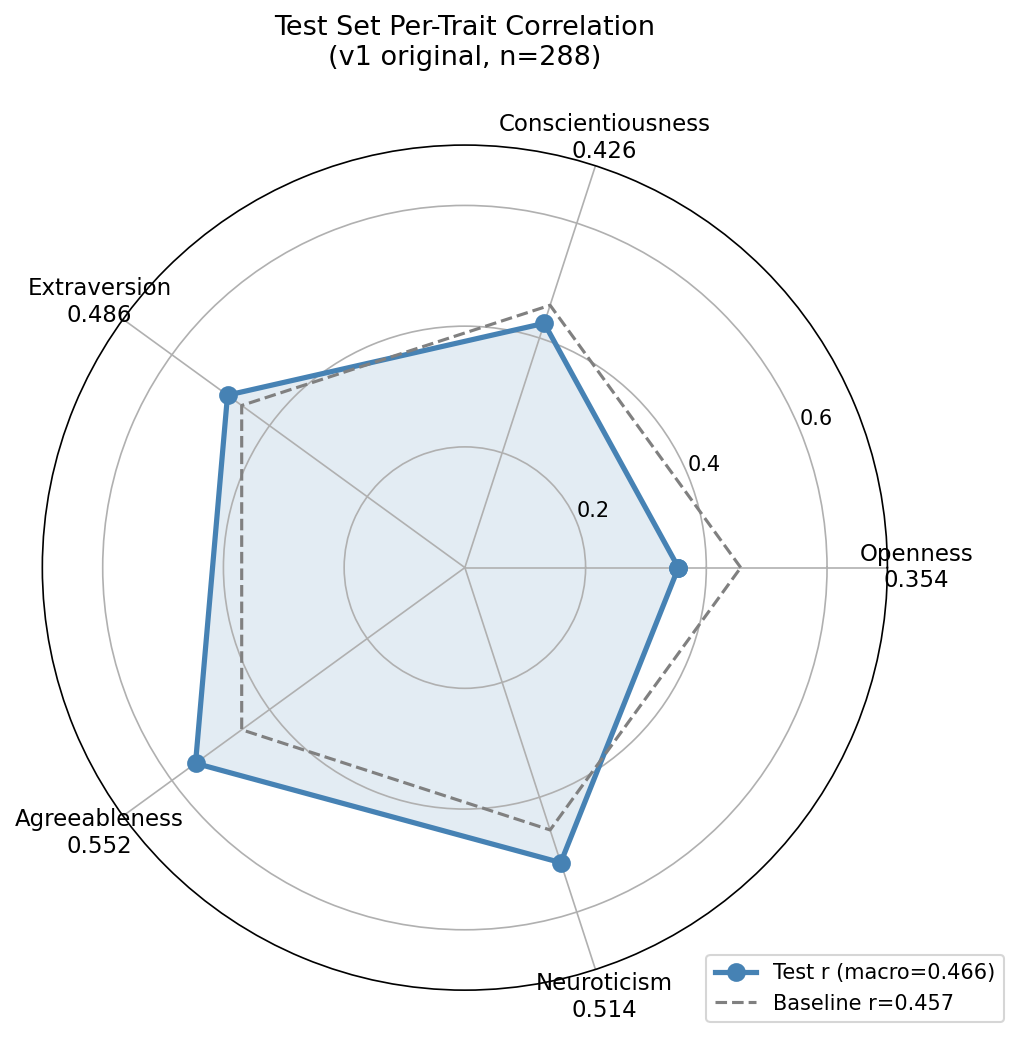

In [6]:
# ═══════════════════════════════════════════════════════════════════
# SLIDE 4: Test Set — Per-trait radar chart (v1 vs baseline)
# ═══════════════════════════════════════════════════════════════════
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

angles = np.linspace(0, 2*np.pi, 5, endpoint=False).tolist()
angles += angles[:1]

v1_rs = [pearson_mae(v1_test, t)[0] for t in TRAITS]
v1_rs += v1_rs[:1]
baseline_rs = [BASELINE] * 5 + [BASELINE]

ax.fill(angles, v1_rs, alpha=0.15, color="steelblue")
ax.plot(angles, v1_rs, "o-", color="steelblue", lw=2.5, markersize=8, label=f"Test r (macro={np.mean(v1_rs[:5]):.3f})")
ax.plot(angles, baseline_rs, "--", color="gray", lw=1.5, label=f"Baseline r={BASELINE}")

ax.set_xticks(angles[:-1])
ax.set_xticklabels([f"{TN[t]}\n{v1_rs[i]:.3f}" for i, t in enumerate(TRAITS)], fontsize=11)
ax.set_ylim(0, 0.7)
ax.set_rticks([0.2, 0.4, 0.6])
ax.set_title("Test Set Per-Trait Correlation\n(v1 original, n=288)", y=1.08, fontsize=13)
ax.legend(loc="lower right", bbox_to_anchor=(1.15, -0.05), fontsize=10)
plt.tight_layout()
plt.savefig("slide_radar_test.png")
plt.show()

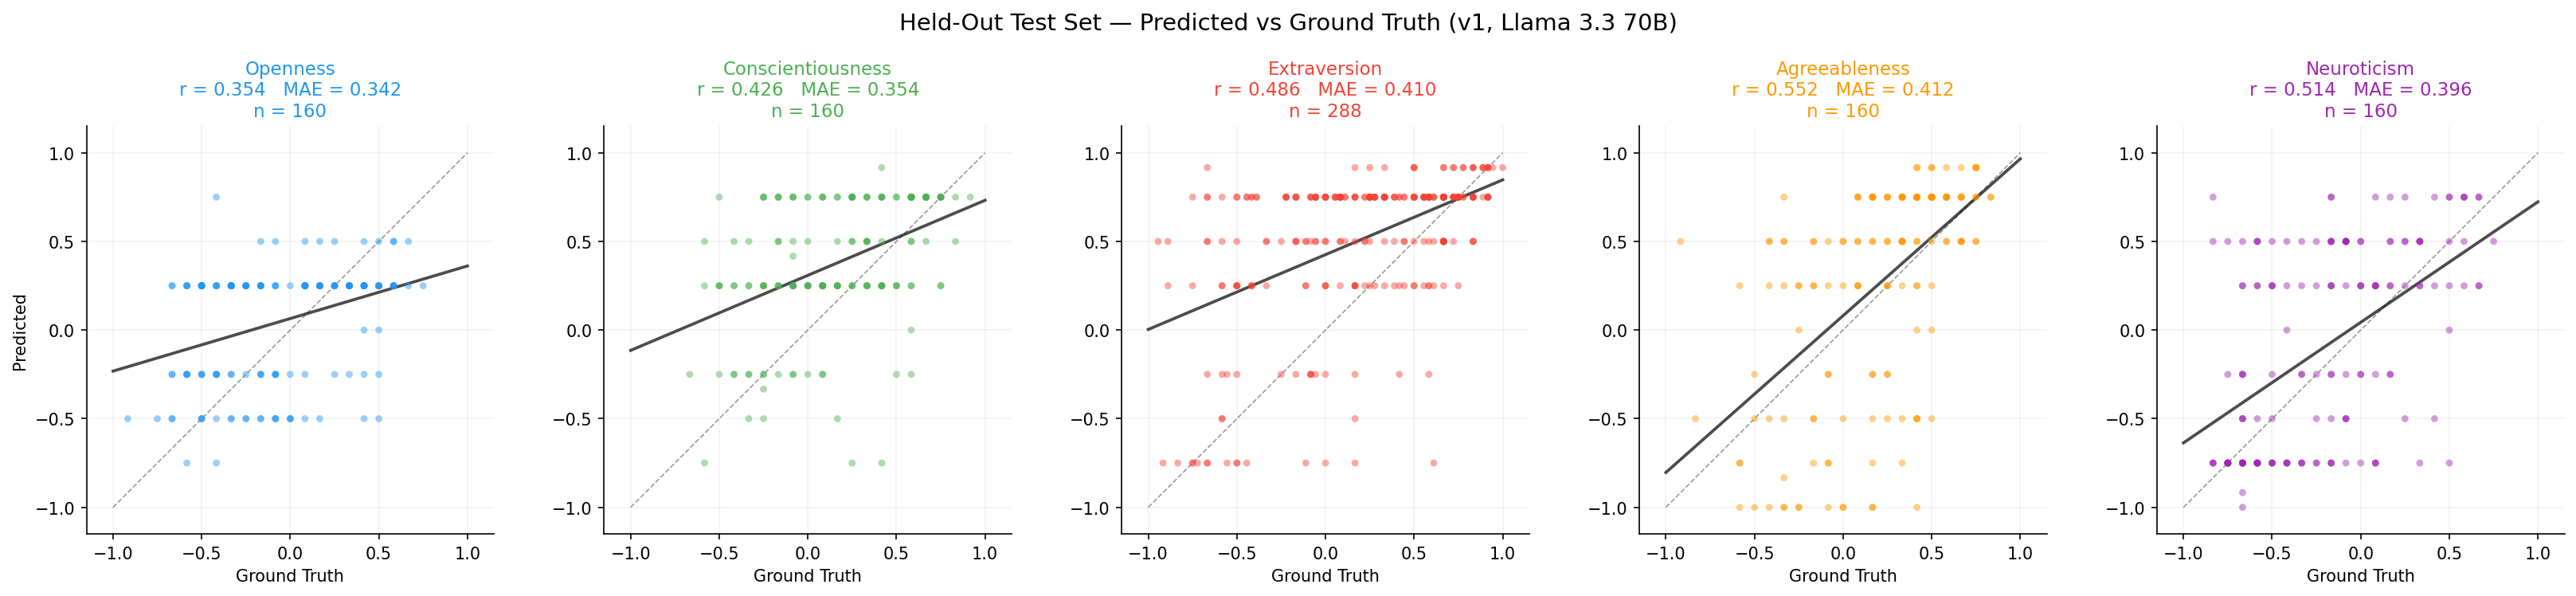

In [7]:
# ═══════════════════════════════════════════════════════════════════
# SLIDE 5: Test Set — 5-trait scatter (predicted vs GT)
# ═══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 5, figsize=(22, 4.5))

for ax, t in zip(axes, TRAITS):
    pairs = [(r["detected_ocean"][t], r["ground_truth_ocean"][t])
             for r in v1_test if t in r.get("ground_truth_ocean", {}) and t in r.get("detected_ocean", {})]
    if not pairs:
        continue
    pred = np.array([p[0] for p in pairs])
    gt = np.array([p[1] for p in pairs])
    r_val, _ = stats.pearsonr(pred, gt)
    mae = np.mean(np.abs(pred - gt))

    ax.scatter(gt, pred, s=18, alpha=0.45, color=COLORS[t], edgecolors="none", zorder=3)
    ax.plot([-1, 1], [-1, 1], "k--", lw=0.8, alpha=0.4)
    z = np.polyfit(gt, pred, 1)
    xf = np.linspace(-1, 1, 100)
    ax.plot(xf, np.polyval(z, xf), color="black", lw=1.8, alpha=0.7)

    ax.set_xlim(-1.15, 1.15)
    ax.set_ylim(-1.15, 1.15)
    ax.set_aspect("equal")
    ax.set_xlabel("Ground Truth", fontsize=10)
    if t == "O":
        ax.set_ylabel("Predicted", fontsize=10)
    ax.set_title(f"{TN[t]}\nr = {r_val:.3f}   MAE = {mae:.3f}\nn = {len(pairs)}", fontsize=11, color=COLORS[t])
    ax.grid(alpha=0.15)

fig.suptitle("Held-Out Test Set — Predicted vs Ground Truth (v1, Llama 3.3 70B)", fontsize=14, y=1.04)
plt.tight_layout()
plt.savefig("slide_scatter_test_5trait.png")
plt.show()

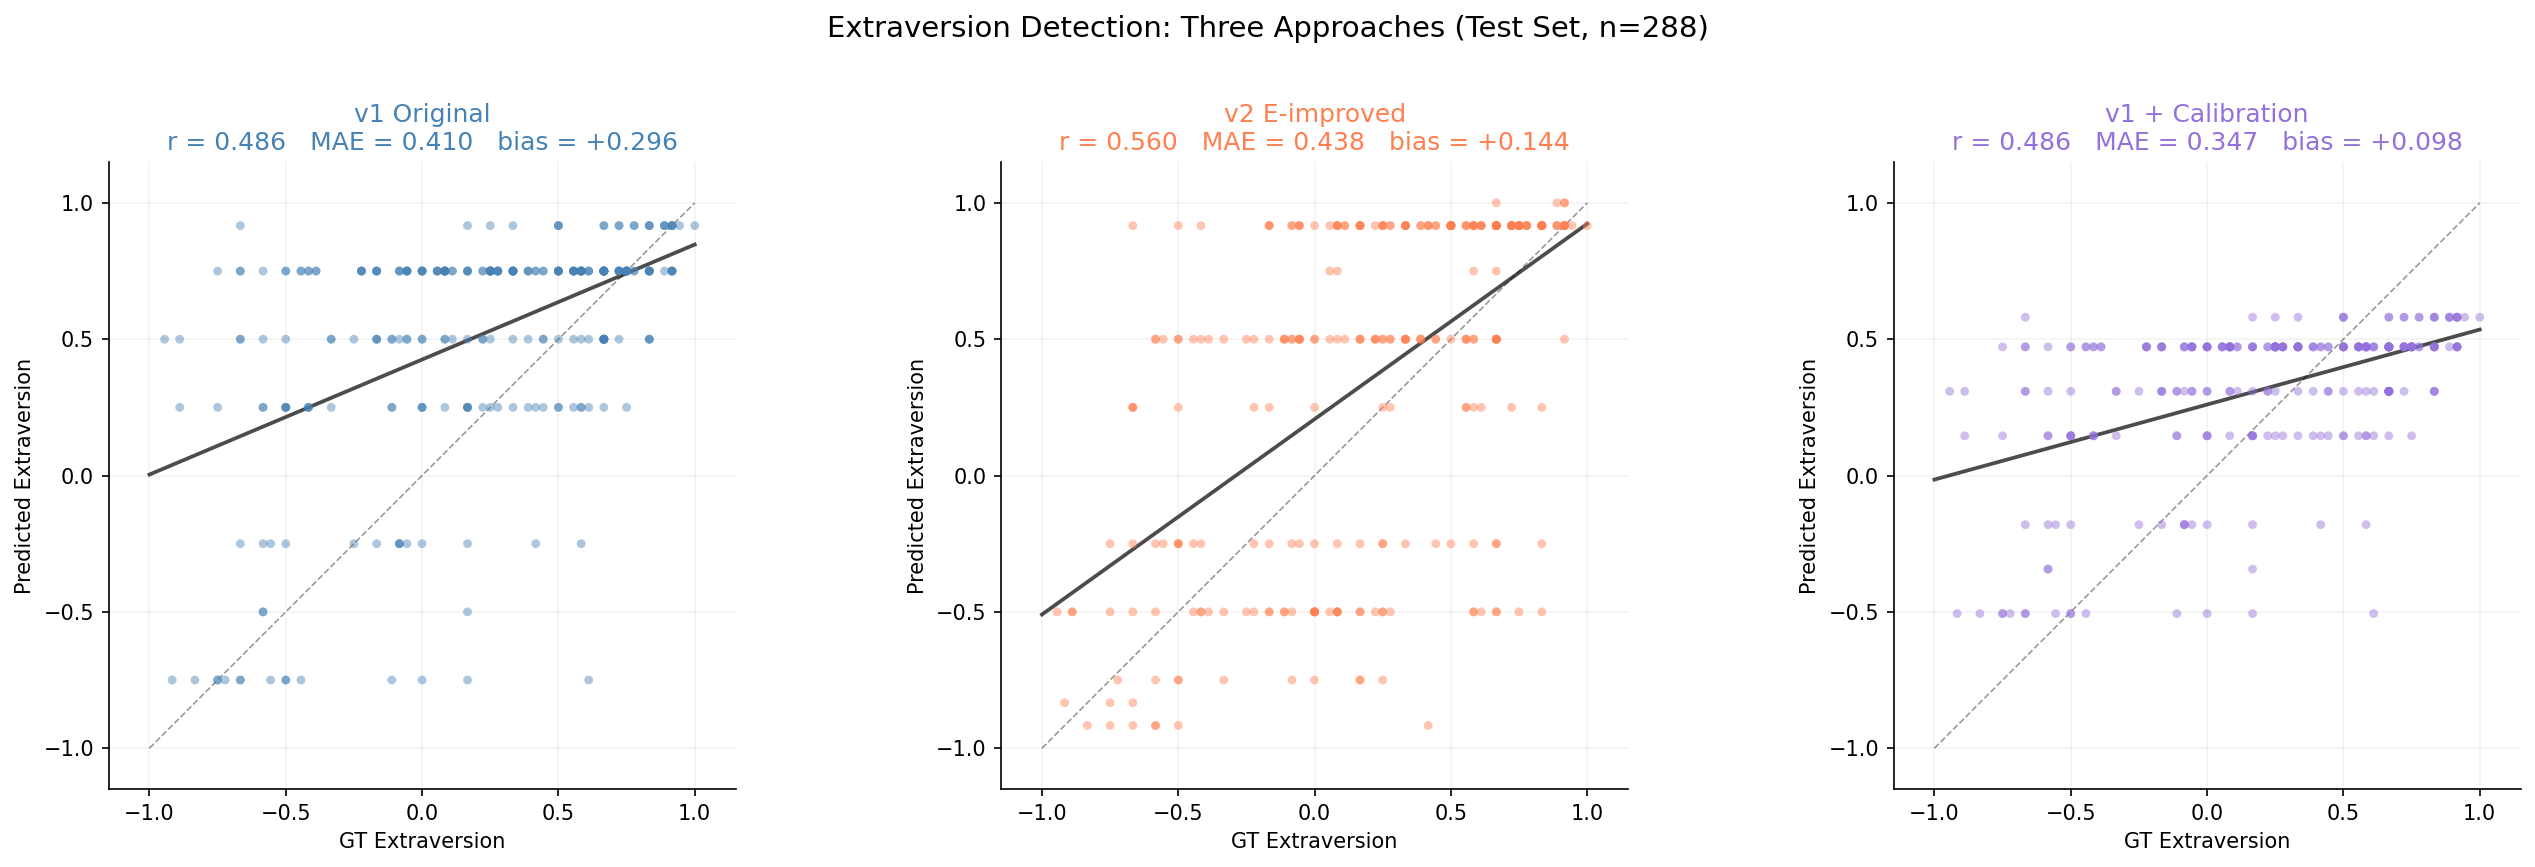

In [8]:
# ═══════════════════════════════════════════════════════════════════
# SLIDE 6: E-Improvement — v1 vs v2 vs calibration
# ═══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for ax, (label, rows, ecal, color) in zip(axes, [
    ("v1 Original", v1_test, None, "steelblue"),
    ("v2 E-improved", v2_test, None, "coral"),
    ("v1 + Calibration", v1_test, (slope, intercept), "mediumpurple")]):
    pairs = [(r["detected_ocean"]["E"], r["ground_truth_ocean"]["E"])
             for r in rows if "E" in r.get("ground_truth_ocean", {}) and "E" in r.get("detected_ocean", {})]
    pred = np.array([p[0] for p in pairs])
    gt = np.array([p[1] for p in pairs])
    if ecal:
        pred = np.clip(ecal[0]*pred + ecal[1], -1, 1)
    r_val, _ = stats.pearsonr(pred, gt)
    mae = np.mean(np.abs(pred - gt))
    bias = np.mean(pred - gt)

    ax.scatter(gt, pred, s=18, alpha=0.45, color=color, edgecolors="none", zorder=3)
    ax.plot([-1, 1], [-1, 1], "k--", lw=0.8, alpha=0.4)
    z = np.polyfit(gt, pred, 1)
    xf = np.linspace(-1, 1, 100)
    ax.plot(xf, np.polyval(z, xf), color="black", lw=1.8, alpha=0.7)
    ax.set_xlim(-1.15, 1.15)
    ax.set_ylim(-1.15, 1.15)
    ax.set_aspect("equal")
    ax.set_xlabel("GT Extraversion", fontsize=10)
    ax.set_ylabel("Predicted Extraversion", fontsize=10)
    ax.set_title(f"{label}\nr = {r_val:.3f}   MAE = {mae:.3f}   bias = {bias:+.3f}", fontsize=12, color=color)
    ax.grid(alpha=0.15)

fig.suptitle("Extraversion Detection: Three Approaches (Test Set, n=288)", fontsize=14, y=1.03)
plt.tight_layout()
plt.savefig("slide_E_improvement.png")
plt.show()

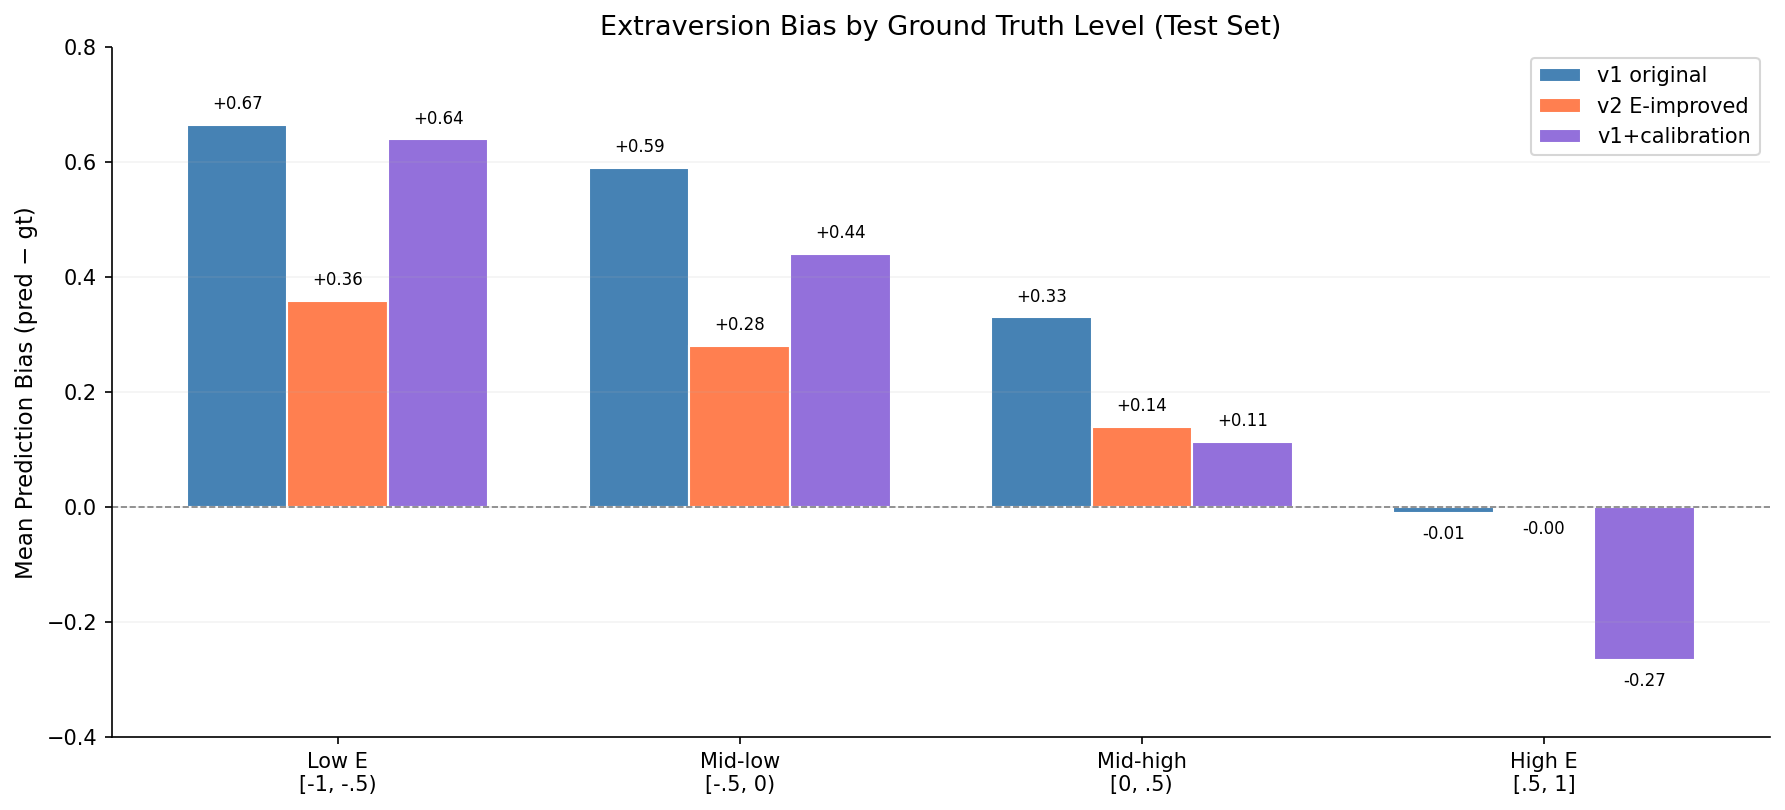

In [9]:
# ═══════════════════════════════════════════════════════════════════
# SLIDE 7: E bias by GT bin — side-by-side comparison
# ═══════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 5.5))

bins_e = [(-1.0, -0.5), (-0.5, 0.0), (0.0, 0.5), (0.5, 1.0)]
bin_labels = ["Low E\n[-1, -.5)", "Mid-low\n[-.5, 0)", "Mid-high\n[0, .5)", "High E\n[.5, 1]"]

x = np.arange(4)
w = 0.25

for i, (label, rows, ecal, color) in enumerate([
    ("v1 original", v1_test, None, "steelblue"),
    ("v2 E-improved", v2_test, None, "coral"),
    ("v1+calibration", v1_test, (slope, intercept), "mediumpurple")]):
    pairs = [(r["detected_ocean"]["E"], r["ground_truth_ocean"]["E"])
             for r in rows if "E" in r.get("ground_truth_ocean", {}) and "E" in r.get("detected_ocean", {})]
    pred = np.array([p[0] for p in pairs])
    gt = np.array([p[1] for p in pairs])
    if ecal:
        pred = np.clip(ecal[0]*pred + ecal[1], -1, 1)

    biases = []
    for lo, hi in bins_e:
        mask = (gt >= lo) & (gt < hi + 0.01)
        biases.append((pred[mask] - gt[mask]).mean() if mask.sum() >= 2 else 0)
    bars = ax.bar(x + i*w - w, biases, w, label=label, color=color, edgecolor="white")
    for bar, b in zip(bars, biases):
        ax.text(bar.get_x() + bar.get_width()/2, b + 0.02 * (1 if b >= 0 else -1),
                f"{b:+.2f}", ha="center", fontsize=8, va="bottom" if b >= 0 else "top")

ax.axhline(0, color="gray", ls="--", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(bin_labels, fontsize=10)
ax.set_ylabel("Mean Prediction Bias (pred − gt)", fontsize=11)
ax.set_title("Extraversion Bias by Ground Truth Level (Test Set)", fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(-0.4, 0.8)
ax.grid(axis="y", alpha=0.15)
plt.tight_layout()
plt.savefig("slide_E_bias_bins.png")
plt.show()

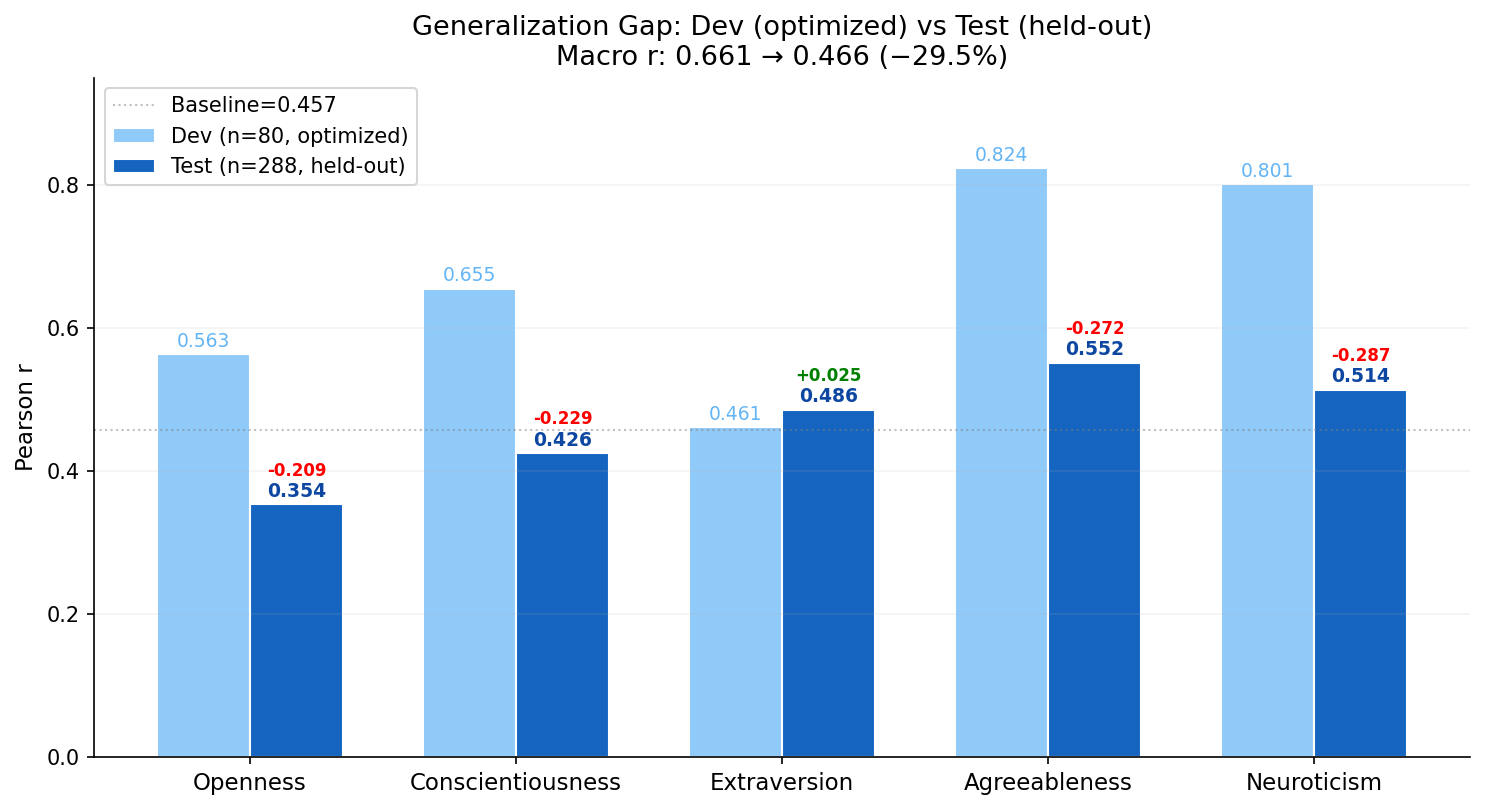

In [10]:
# ═══════════════════════════════════════════════════════════════════
# SLIDE 8: Dev vs Test generalization gap
# ═══════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 5.5))

dev_rs = {"O": 0.563, "C": 0.655, "E": 0.461, "A": 0.824, "N": 0.801}
test_rs = {t: pearson_mae(v1_test, t)[0] for t in TRAITS}

x = np.arange(5)
w = 0.35
bars_dev = ax.bar(x - w/2, [dev_rs[t] for t in TRAITS], w, label="Dev (n=80, optimized)", color="#90CAF9", edgecolor="white")
bars_test = ax.bar(x + w/2, [test_rs[t] for t in TRAITS], w, label="Test (n=288, held-out)", color="#1565C0", edgecolor="white")

for bar, v in zip(bars_dev, [dev_rs[t] for t in TRAITS]):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f"{v:.3f}", ha="center", fontsize=9, color="#64B5F6")
for bar, v in zip(bars_test, [test_rs[t] for t in TRAITS]):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f"{v:.3f}", ha="center", fontsize=9, fontweight="bold", color="#0D47A1")

# Gap arrows
for i, t in enumerate(TRAITS):
    gap = test_rs[t] - dev_rs[t]
    color = "green" if gap > 0 else "red"
    ax.annotate(f"{gap:+.3f}", xy=(i + w/2, test_rs[t] + 0.04),
                fontsize=8, ha="center", color=color, fontweight="bold")

ax.axhline(BASELINE, color="gray", ls=":", lw=1, alpha=0.5, label=f"Baseline={BASELINE}")
ax.set_xticks(x)
ax.set_xticklabels([TN[t] for t in TRAITS], fontsize=11)
ax.set_ylabel("Pearson r")
ax.set_title("Generalization Gap: Dev (optimized) vs Test (held-out)\nMacro r: 0.661 → 0.466 (−29.5%)", fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(0, 0.95)
ax.grid(axis="y", alpha=0.15)
plt.tight_layout()
plt.savefig("slide_generalization_gap.png")
plt.show()

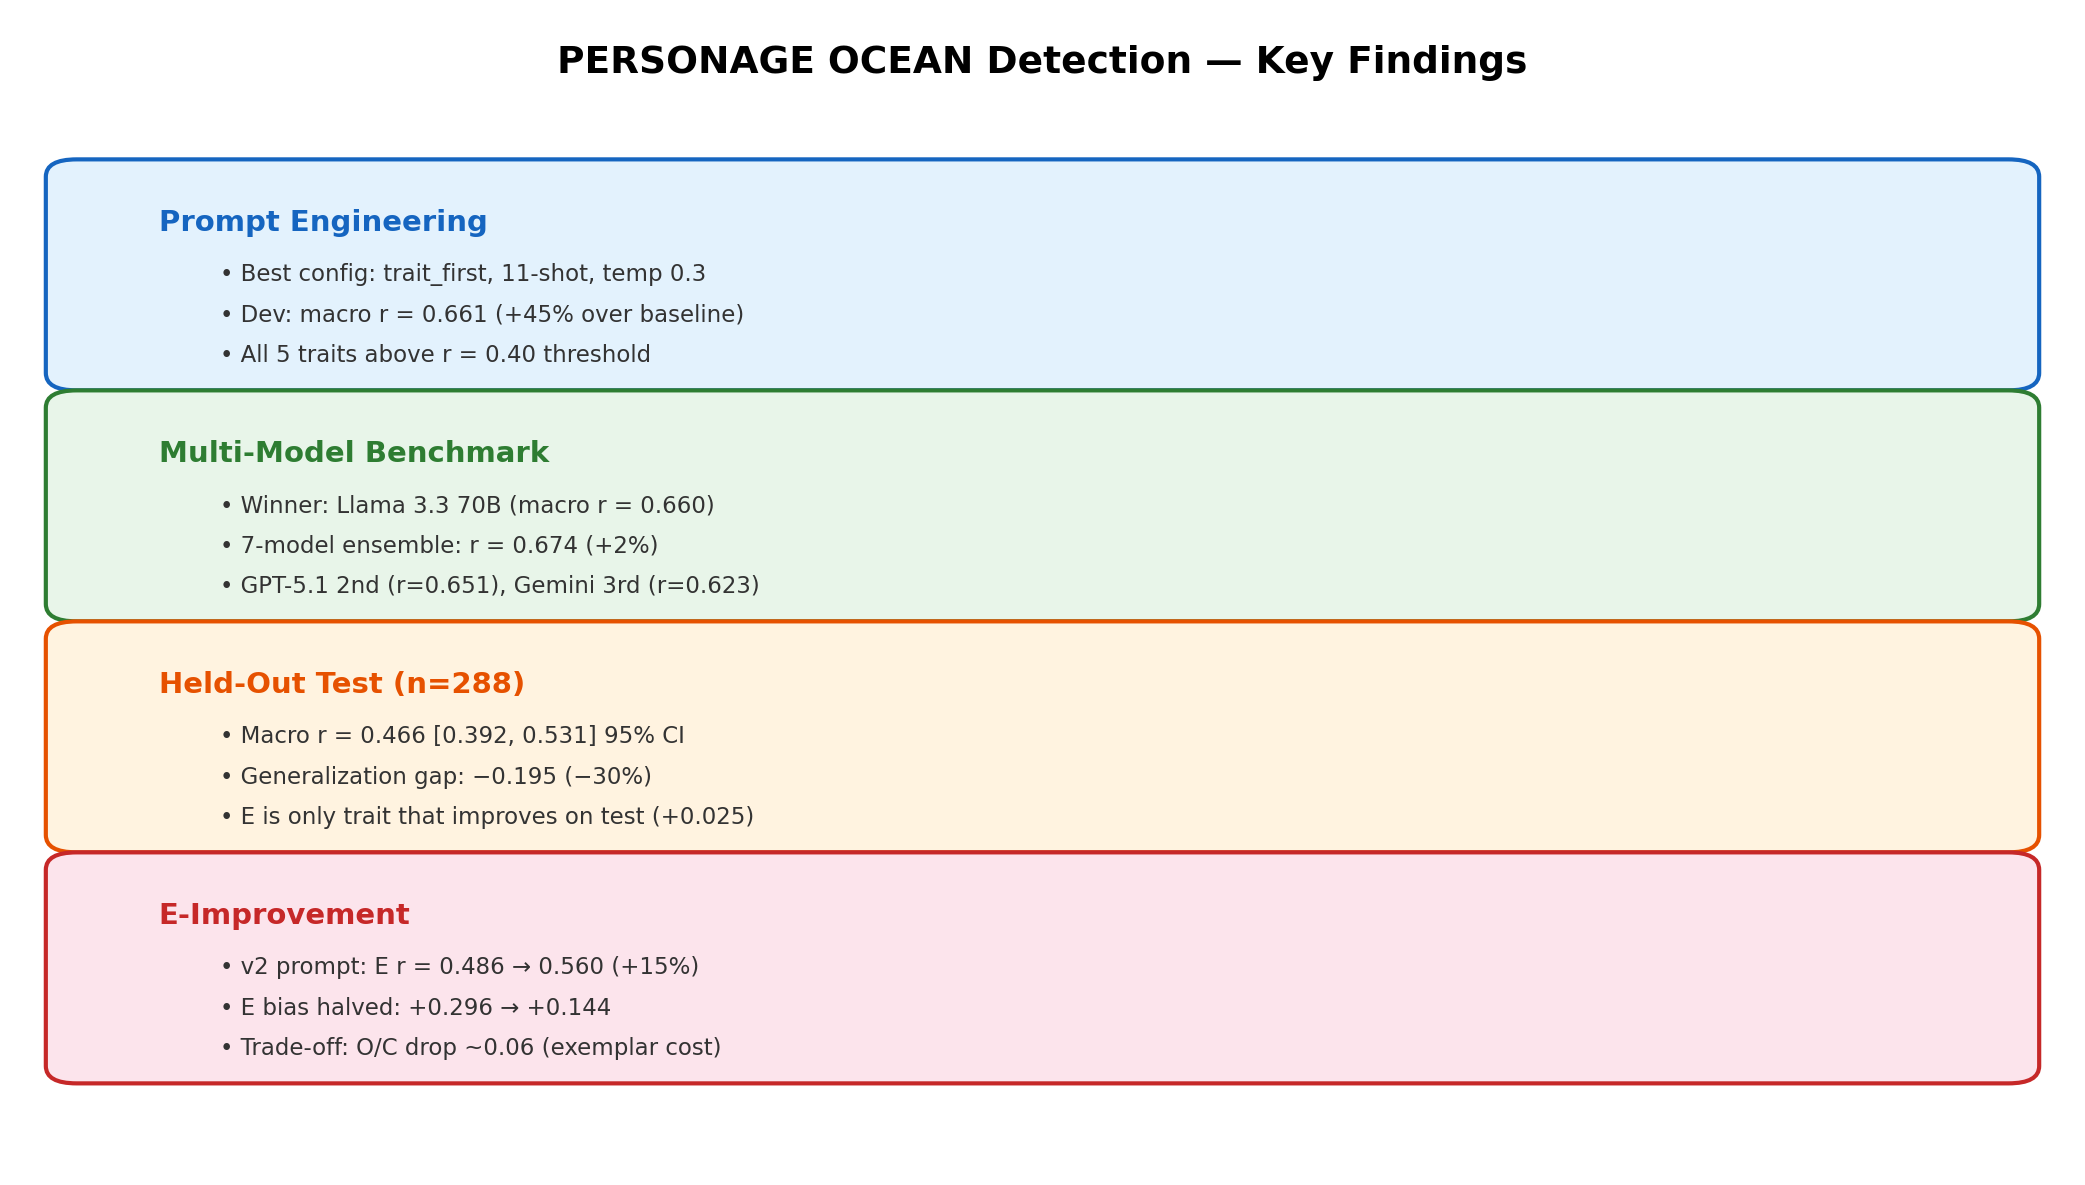

In [11]:
# ═══════════════════════════════════════════════════════════════════
# SLIDE 9: Key Findings Summary Card
# ═══════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis("off")

# Title
ax.text(5, 9.5, "PERSONAGE OCEAN Detection — Key Findings", ha="center", fontsize=18, fontweight="bold")

# Cards
cards = [
    ("#E3F2FD", "#1565C0", "Prompt Engineering", [
        "Best config: trait_first, 11-shot, temp 0.3",
        "Dev: macro r = 0.661 (+45% over baseline)",
        "All 5 traits above r = 0.40 threshold",
    ]),
    ("#E8F5E9", "#2E7D32", "Multi-Model Benchmark", [
        "Winner: Llama 3.3 70B (macro r = 0.660)",
        "7-model ensemble: r = 0.674 (+2%)",
        "GPT-5.1 2nd (r=0.651), Gemini 3rd (r=0.623)",
    ]),
    ("#FFF3E0", "#E65100", "Held-Out Test (n=288)", [
        f"Macro r = 0.466 [0.392, 0.531] 95% CI",
        "Generalization gap: −0.195 (−30%)",
        "E is only trait that improves on test (+0.025)",
    ]),
    ("#FCE4EC", "#C62828", "E-Improvement", [
        "v2 prompt: E r = 0.486 → 0.560 (+15%)",
        "E bias halved: +0.296 → +0.144",
        "Trade-off: O/C drop ~0.06 (exemplar cost)",
    ]),
]

for i, (bg, fg, title, points) in enumerate(cards):
    y = 7.5 - i * 2.0
    rect = mpatches.FancyBboxPatch((0.3, y - 0.6), 9.4, 1.7, boxstyle="round,pad=0.15",
                                    facecolor=bg, edgecolor=fg, lw=2)
    ax.add_patch(rect)
    ax.text(0.7, y + 0.7, title, fontsize=14, fontweight="bold", color=fg, va="center")
    for j, pt in enumerate(points):
        ax.text(1.0, y + 0.25 - j * 0.35, f"• {pt}", fontsize=11, va="center", color="#333333")

plt.tight_layout()
plt.savefig("slide_key_findings.png")
plt.show()

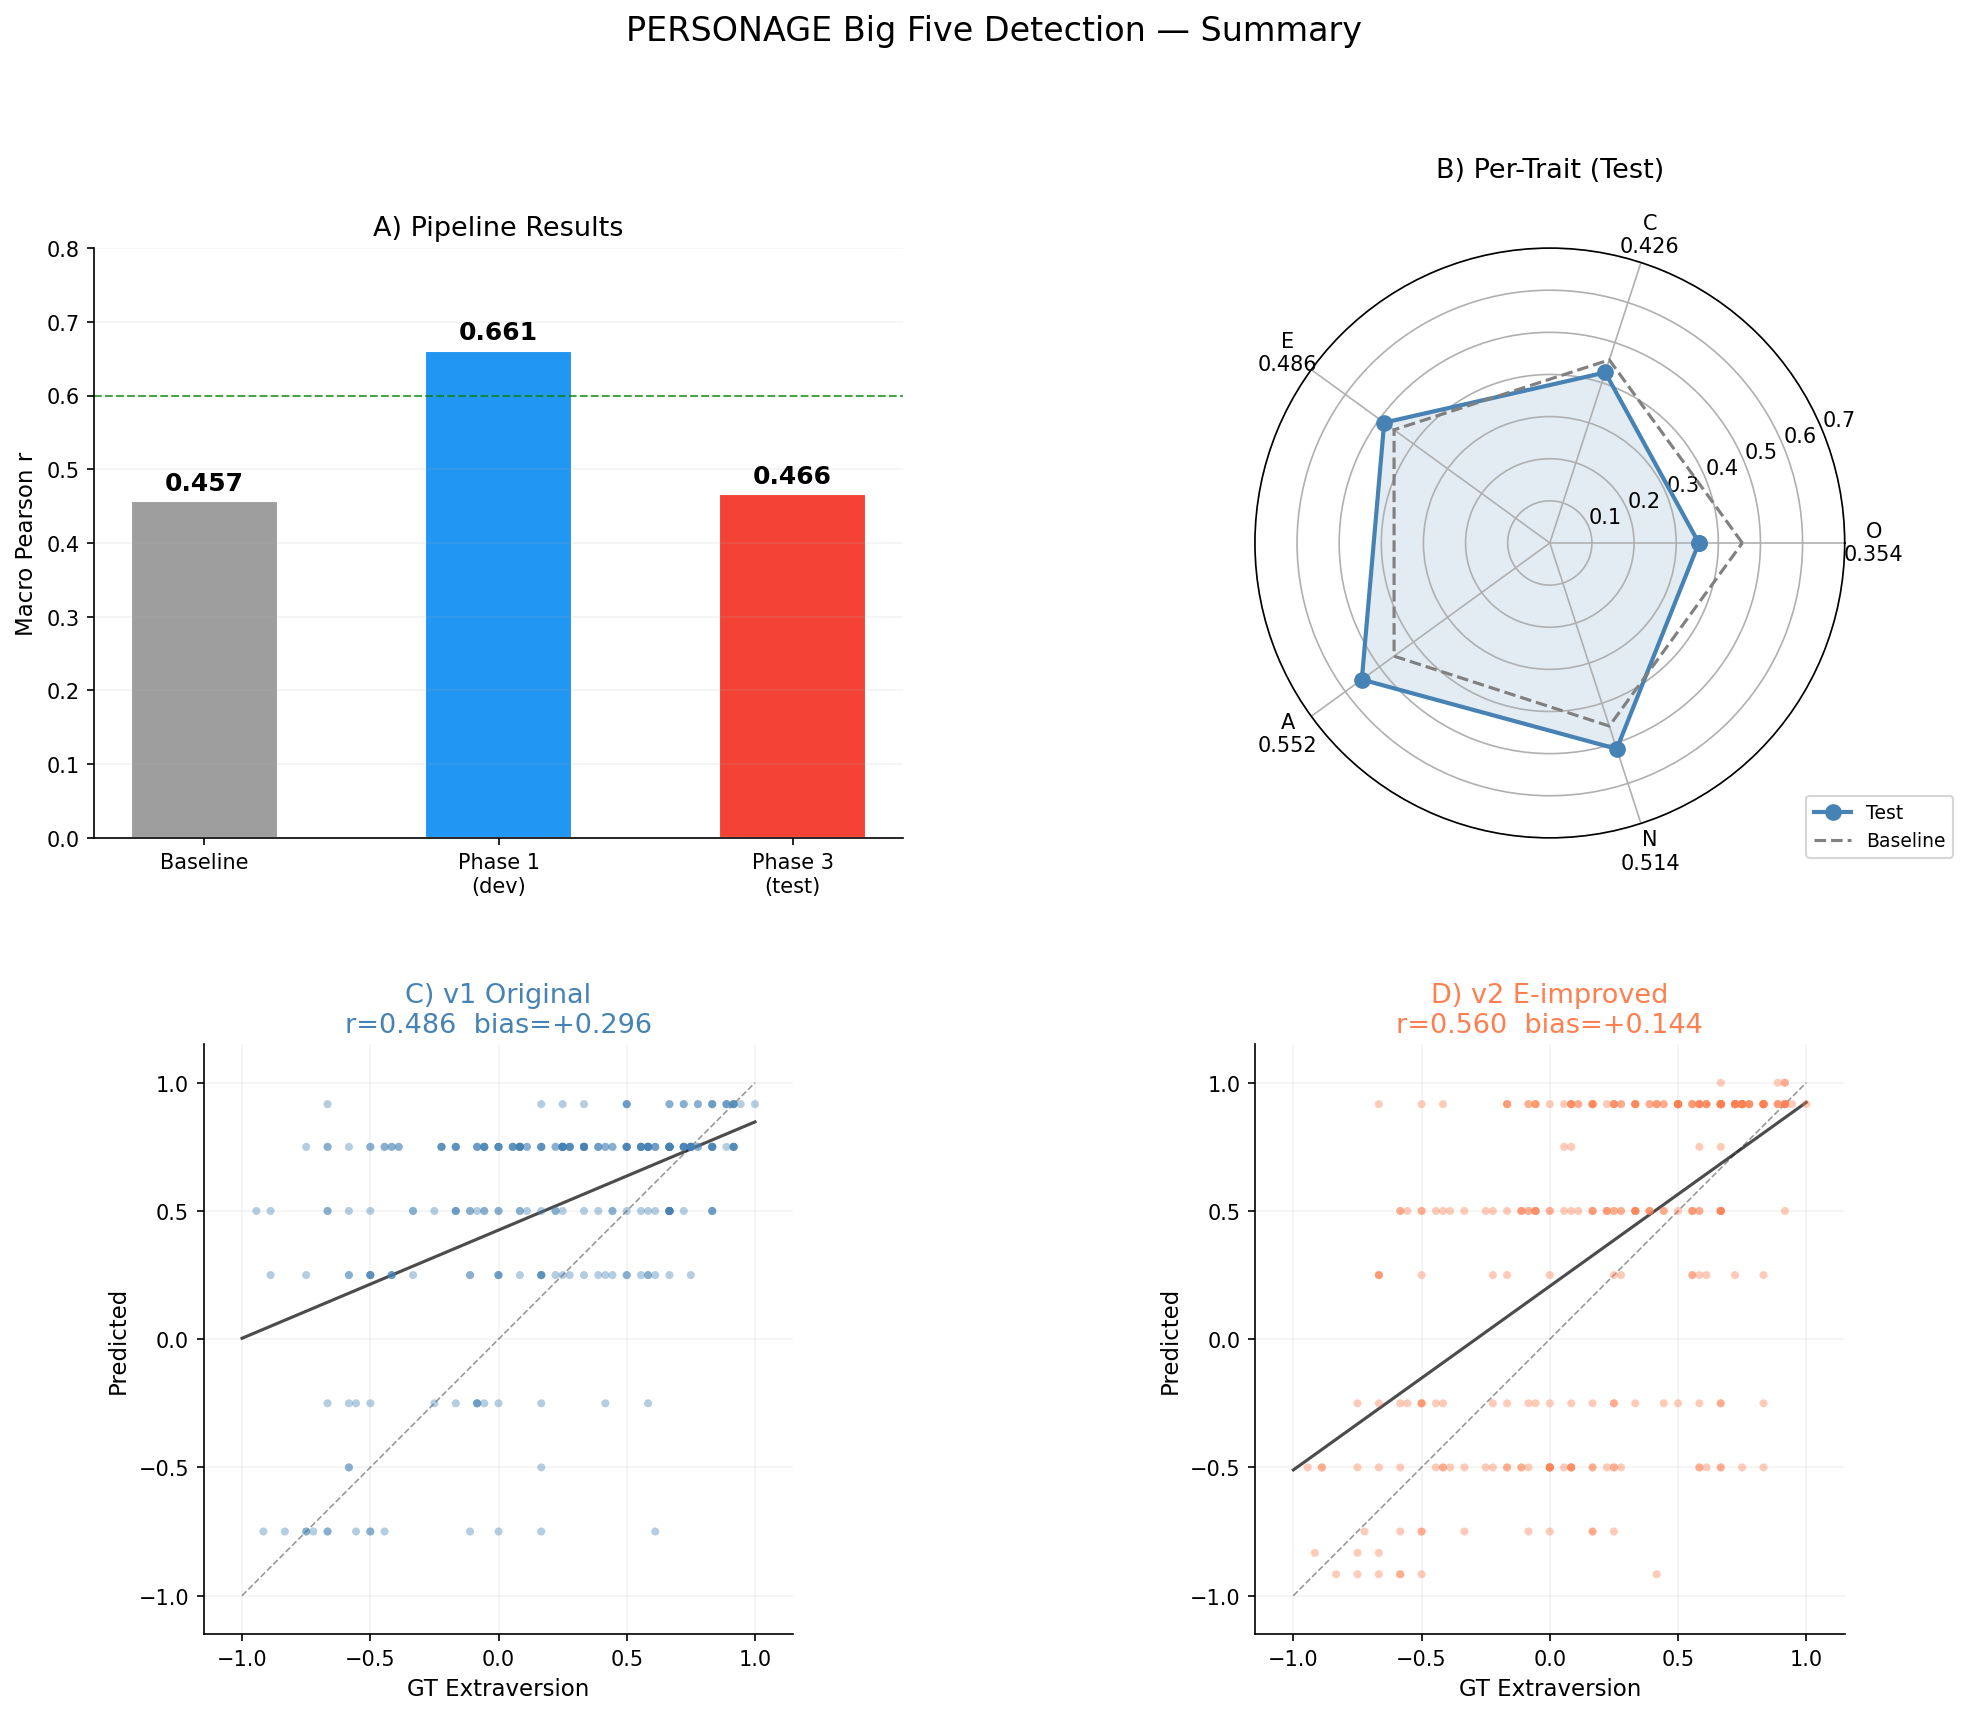

In [12]:
# ═══════════════════════════════════════════════════════════════════
# SLIDE 10: Final comprehensive figure — 2x2 grid
# ═══════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 2, hspace=0.35, wspace=0.3)

# A) Pipeline waterfall
ax = fig.add_subplot(gs[0, 0])
stages_s = ["Baseline", "Phase 1\n(dev)", "Phase 3\n(test)"]
vals_s = [0.457, 0.661, 0.466]
cols_s = ["#9E9E9E", "#2196F3", "#F44336"]
bars = ax.bar(range(3), vals_s, color=cols_s, edgecolor="white", width=0.5)
for bar, v in zip(bars, vals_s):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.015, f"{v:.3f}", ha="center", fontsize=12, fontweight="bold")
ax.axhline(0.60, color="green", ls="--", lw=1, alpha=0.7)
ax.set_xticks(range(3))
ax.set_xticklabels(stages_s, fontsize=10)
ax.set_ylabel("Macro Pearson r")
ax.set_title("A) Pipeline Results", fontsize=13)
ax.set_ylim(0, 0.8)
ax.grid(axis="y", alpha=0.15)

# B) Radar
ax = fig.add_subplot(gs[0, 1], polar=True)
angles = np.linspace(0, 2*np.pi, 5, endpoint=False).tolist() + [0]
v1_r = [pearson_mae(v1_test, t)[0] for t in TRAITS] + [pearson_mae(v1_test, "O")[0]]
bl_r = [BASELINE]*6
ax.fill(angles, v1_r, alpha=0.15, color="steelblue")
ax.plot(angles, v1_r, "o-", color="steelblue", lw=2, markersize=7, label="Test")
ax.plot(angles, bl_r, "--", color="gray", lw=1.5, label="Baseline")
ax.set_xticks(angles[:-1])
ax.set_xticklabels([f"{t}\n{v1_r[i]:.3f}" for i, t in enumerate(TRAITS)], fontsize=10)
ax.set_ylim(0, 0.7)
ax.set_title("B) Per-Trait (Test)", fontsize=13, y=1.1)
ax.legend(loc="lower right", bbox_to_anchor=(1.2, -0.05), fontsize=9)

# C) E scatter v1 vs v2
for idx, (label, rows, ecal, color) in enumerate([
    ("v1 Original", v1_test, None, "steelblue"),
    ("v2 E-improved", v2_test, None, "coral")]):
    ax = fig.add_subplot(gs[1, idx])
    pairs = [(r["detected_ocean"]["E"], r["ground_truth_ocean"]["E"])
             for r in rows if "E" in r.get("ground_truth_ocean", {}) and "E" in r.get("detected_ocean", {})]
    pred = np.array([p[0] for p in pairs])
    gt = np.array([p[1] for p in pairs])
    r_val, _ = stats.pearsonr(pred, gt)
    bias = np.mean(pred - gt)
    ax.scatter(gt, pred, s=15, alpha=0.4, color=color, edgecolors="none", zorder=3)
    ax.plot([-1, 1], [-1, 1], "k--", lw=0.8, alpha=0.4)
    z = np.polyfit(gt, pred, 1)
    ax.plot(np.linspace(-1,1,100), np.polyval(z, np.linspace(-1,1,100)), color="black", lw=1.5, alpha=0.7)
    ax.set_xlim(-1.15, 1.15)
    ax.set_ylim(-1.15, 1.15)
    ax.set_aspect("equal")
    ax.set_xlabel("GT Extraversion")
    ax.set_ylabel("Predicted")
    panel = "C" if idx == 0 else "D"
    ax.set_title(f"{panel}) {label}\nr={r_val:.3f}  bias={bias:+.3f}", fontsize=13, color=color)
    ax.grid(alpha=0.15)

fig.suptitle("PERSONAGE Big Five Detection — Summary", fontsize=16, y=1.01)
plt.savefig("slide_summary_2x2.png")
plt.show()

In [13]:
print("Saved figures:")
for f in sorted(Path(".").glob("slide_*.png")):
    print(f"  {f.name}")

Saved figures:
  slide_E_bias_bins.png
  slide_E_improvement.png
  slide_generalization_gap.png
  slide_key_findings.png
  slide_model_ranking.png
  slide_multimodel_benchmark.png
  slide_pipeline_overview.png
  slide_radar_test.png
  slide_scatter_test_5trait.png
  slide_summary_2x2.png
